# Unsupervised Analysis of Protein–Protein Interfaces
---
This notebook performs an **unsupervised analysis** of protein–protein interface (PPI) clustering results produced by GMM and VBGMM models.  
The analysis is structured in four parts:

1. **ANOVA assumption check** — verifies that ANOVA assumptions (normality, homoscedasticity) are violated, justifying the use of the non-parametric Kruskal-Wallis test.
2. **Pipeline setup** — loads the `unsupervised_analysis` module and defines the end-to-end model pipeline.
3. **Hierarchical superclustering & dendrograms** — agglomerates fine-grained clusters into superclusters and visualises their relationships.
4. **Effect size analysis** — quantifies how well each physicochemical feature discriminates between superclusters using Kruskal-Wallis effect sizes with Benjamini-Hochberg correction.

## 1 · ANOVA Assumption Check

Before choosing a statistical test for feature discriminability, we verify whether parametric ANOVA assumptions hold across the cluster assignments from VBGMM.

**Two assumptions are tested for each feature:**
- **Normality of residuals** — Shapiro-Wilk test on ANOVA residuals (p > 0.05 = normal)
- **Homoscedasticity (equal variance)** — Brown-Forsythe variant of Levene's test (p > 0.05 = equal variance)

If either assumption is violated for the majority of features, the **non-parametric Kruskal-Wallis test** is preferred over ANOVA.

> **Figure 1** shows per-feature diagnostics (boxplot, QQ plot, variance bars) for the top-N most variable features.  


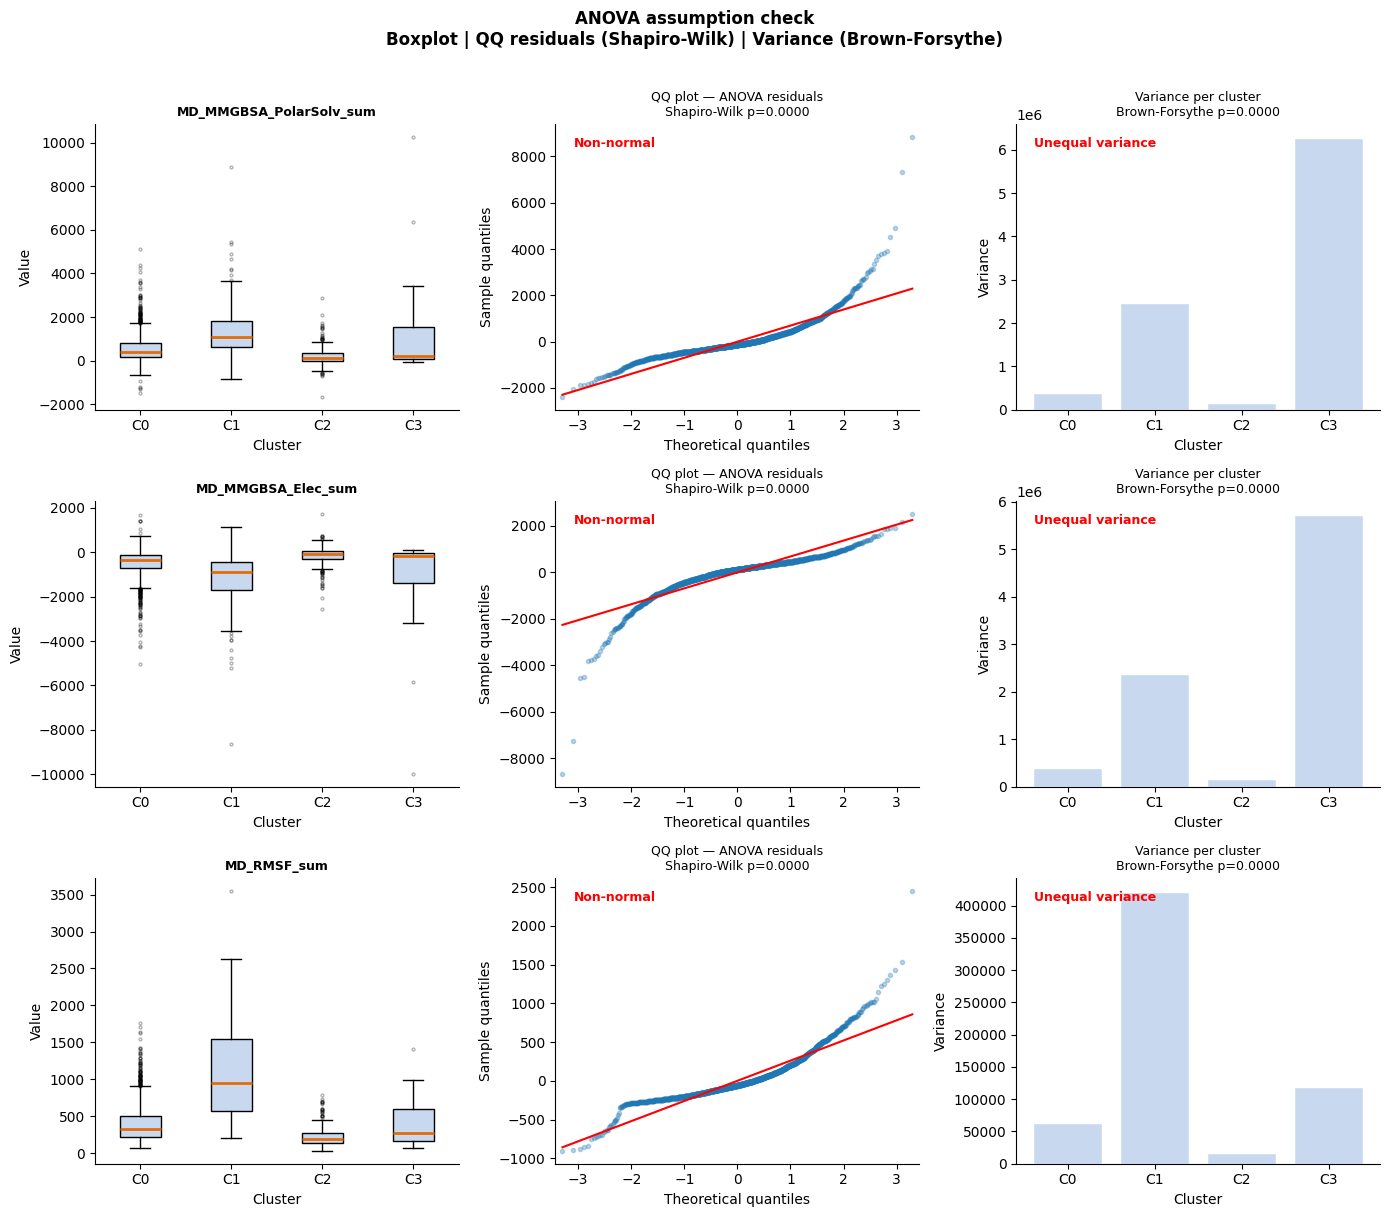

,feature,p_shapiro,p_levene,normal,equal_var
0,MD_MMGBSA_VdW_mean,1.326523e-04,1.204214e-09,False,False
1,MD_MMGBSA_Elec_mean,2.424079e-40,5.720159e-01,False,True
2,MD_MMGBSA_PolarSolv_mean,2.752062e-40,5.214431e-01,False,True
3,MD_MMGBSA_NonPolarSolv_mean,1.908719e-08,1.719331e-08,False,False
4,MD_RMSF_mean,3.640957e-29,4.577925e-06,False,False
...,...,...,...,...,...
60,Contact_per_Interface,2.697078e-18,1.214839e-10,False,False
61,AF_Fraction_Disordered,4.947421e-71,2.586613e-25,False,False
62,MD_MMGBSA_total,1.429638e-36,5.508349e-54,False,False
63,MD_MMGBSA_Std_Dev,5.329191e-06,1.089031e-02,False,False


In [15]:
# ══════════════════════════════════════════════════════════════
# ANOVA ASSUMPTION CHECK 
# ══════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import shapiro, levene, bartlett
from statsmodels.formula.api import ols
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import fcluster
from scipy.stats import chi2_contingency, kruskal, f_oneway

# ── config ────────────────────────────────────────────────────
QIN_PATH    = '../results/classical_agg_10_vbgmm_QIn.npy'
EXPIDS_PATH = '../source/agg_trans.csv'
N_FEATURES  = 3   # features to plot in detail

# ── load ──────────────────────────────────────────────────────
QIn    = np.load(QIN_PATH)
exp_df = pd.read_csv(EXPIDS_PATH)
df     = pd.DataFrame({'cluster_assignment': QIn.argmax(axis=1),
                       'ExpID': exp_df['ExpID'].values})
df = df.merge(exp_df, on='ExpID', how='left')

skip = {'cluster_assignment', 'ExpID', 'Transmembrane', 'label'}
feat_cols = [c for c in df.columns if c not in skip
             and pd.api.types.is_numeric_dtype(df[c])]
cluster_order = sorted(df['cluster_assignment'].unique())

# pick N features with most variance across clusters for visual check
top_feats = (df.groupby('cluster_assignment')[feat_cols]
               .mean().std().nlargest(N_FEATURES).index.tolist())


# ── FIGURE 1: per-feature diagnostic ─────────────────────────
fig, axes = plt.subplots(N_FEATURES, 3, figsize=(14, 4*N_FEATURES))

for row, feat in enumerate(top_feats):
    clean = df[['cluster_assignment', feat]].dropna()

    # ── fit proper ANOVA model via statsmodels ────────────────
    model = ols(f'{feat} ~ C(cluster_assignment)', data=clean).fit()
    residuals = model.resid  # ANOVA residuals

    # ── Shapiro-Wilk on ANOVA residuals ──────────────────────
    _, p_sw = shapiro(residuals)

    # ── Levene's test (robust, doesn't assume normality) ──────
    groups = [clean.loc[clean['cluster_assignment']==c, feat].values
              for c in cluster_order]
    _, p_lev = levene(*groups, center='median')  # median = Brown-Forsythe variant, mean is Levene

    # col 0: boxplot
    ax = axes[row, 0]
    ax.boxplot(groups, tick_labels=[f"C{c}" for c in cluster_order],
               patch_artist=True,
               boxprops=dict(facecolor='#C8D9EF'),
               medianprops=dict(color='#E36C09', linewidth=2),
               flierprops=dict(marker='o', markersize=2, alpha=0.3))
    ax.set_title(feat, fontweight='bold', fontsize=9)
    ax.set_xlabel('Cluster'); ax.set_ylabel('Value')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    # col 1: QQ plot of proper ANOVA residuals
    ax = axes[row, 1]
    sm.qqplot(residuals, line='s', ax=ax, alpha=0.3, markersize=3)  # statsmodels QQ
    ax.set_title(f'QQ plot — ANOVA residuals\nShapiro-Wilk p={p_sw:.4f}', fontsize=9)
    ax.set_xlabel('Theoretical quantiles'); ax.set_ylabel('Sample quantiles')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    c = 'green' if p_sw > 0.05 else 'red'
    ax.text(0.05, 0.92, 'Normal' if p_sw > 0.05 else 'Non-normal',
            transform=ax.transAxes, color=c, fontweight='bold', fontsize=9)

    # col 2: variance bar + Levene (Brown-Forsythe)
    ax = axes[row, 2]
    ax.bar([f"C{c}" for c in cluster_order],
           [np.var(g, ddof=1) for g in groups],
           color='#C8D9EF', edgecolor='white')
    ax.set_title(f'Variance per cluster\nBrown-Forsythe p={p_lev:.4f}', fontsize=9)
    ax.set_xlabel('Cluster'); ax.set_ylabel('Variance')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    c = 'green' if p_lev > 0.05 else 'red'
    ax.text(0.05, 0.92, 'Equal variance' if p_lev > 0.05 else 'Unequal variance',
            transform=ax.transAxes, color=c, fontweight='bold', fontsize=9)

plt.suptitle('ANOVA assumption check\nBoxplot | QQ residuals (Shapiro-Wilk) | Variance (Brown-Forsythe)',
             fontweight='bold', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


# ── FIGURE 2: summary across ALL features ────────────────────
norm_fail, lev_fail, total = 0, 0, 0
results = []

for feat in feat_cols:
    clean = df[['cluster_assignment', feat]].dropna()
    groups = [clean.loc[clean['cluster_assignment']==c, feat].values
              for c in cluster_order]
    groups = [g for g in groups if len(g) > 2]
    if len(groups) < 2: continue
    total += 1

    # proper ANOVA residuals via statsmodels
    model = ols(f'{feat} ~ C(cluster_assignment)', data=clean).fit()
    _, p_sw  = shapiro(model.resid)
    _, p_lev = levene(*groups, center='median')

    norm_fail += p_sw  < 0.05
    lev_fail  += p_lev < 0.05
    results.append({'feature': feat, 'p_shapiro': p_sw, 'p_levene': p_lev,
                    'normal': p_sw >= 0.05, 'equal_var': p_lev >= 0.05})

res_df = pd.DataFrame(results)
res_df

## 2 · Pipeline Setup

Here we import the `unsupervised_analysis` module (`usan`) which contains all core functions, and define the `run_model_pipeline` helper that chains them together for a single model:

1. `usan.load_qin_clean` — loads the QIn soft-assignment matrix and removes empty clusters
2. `usan.merge_small_clusters` — merges clusters below the minimum size threshold
3. `usan.plot_dendrograms` — visualises hierarchical cluster relationships (optional)
4. `usan.compute_superclusters` — agglomerates fine clusters into 4 superclusters via Jeffreys divergence
5. `usan.build_supercluster_df` — merges supercluster labels with physicochemical features
6. `usan.compute_effects` — computes Kruskal-Wallis effect sizes with BH correction

In [16]:
basepath="../"
## set the path
import sys
sys.path.append(basepath+"ppi.lib/")
import unsupervised_analysis as usan
import evalmetrics as evms


def run_model_pipeline(name, qin_path, exp_path, agg_df, evms,
                       min_size=10, use_anova=False,
                       make_plots=True):

    print(f"\n=== {name} ===")

    Q, labels = usan.load_qin_clean(qin_path)
    labels_clean = usan.merge_small_clusters(Q, labels, min_size)

    if make_plots:
        usan.plot_dendrograms(Q, labels_clean, evms, title_prefix=name)

    sc = usan.compute_superclusters(Q, labels_clean, evms, min_size)

    df = usan.build_supercluster_df(exp_path, agg_df, sc)
    effects = usan.compute_effects(df, "supercluster", use_anova)

    print("Significant features:", effects["sig"].sum())

    return df, effects

## 3 · Hierarchical Superclustering & Dendrograms

We run the full pipeline for five models spanning two feature representations (aggregated physicochemical features and GNN embeddings) for GMM and VBGMM:

For each model, a dendrogram is shown comparing two inter-cluster distance metrics:
- **Colocation** — based on co-assignment probabilities from QIn
- **Jeffreys** — symmetric KL divergence between cluster QIn distributions


=== AGG-GMM ===


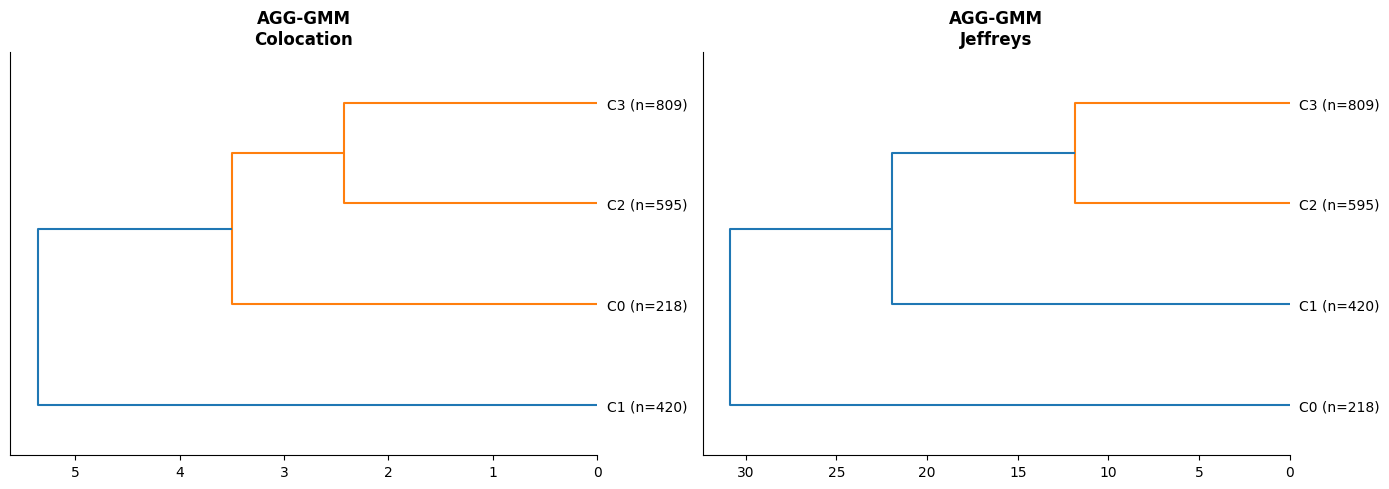

Significant features: 66

=== AGG-VBGMM ===


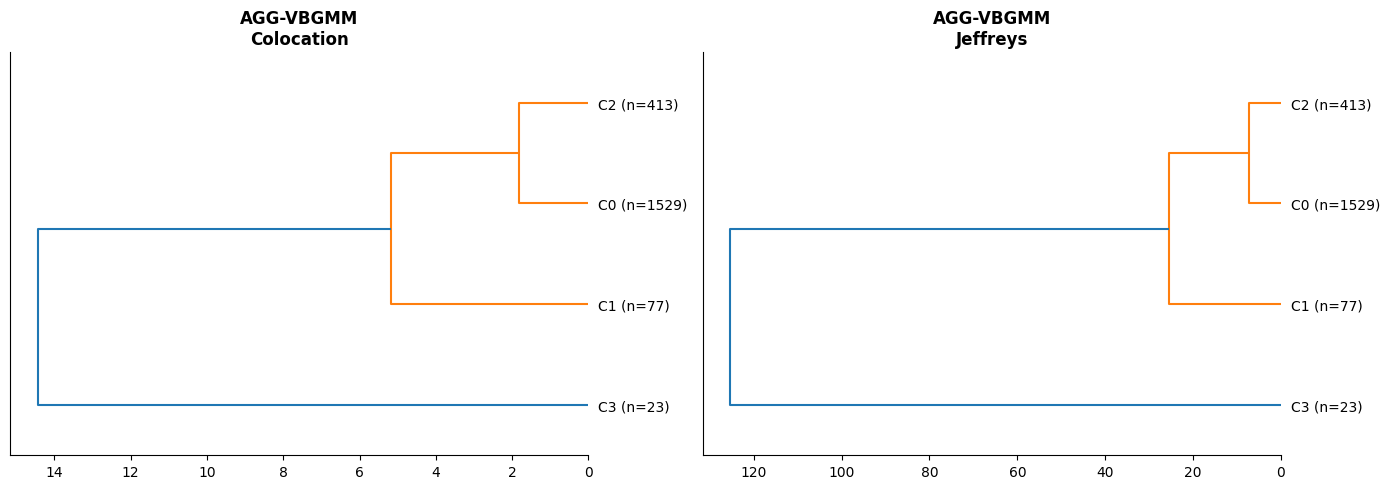

Significant features: 59

=== AGG-VBGMM34 ===


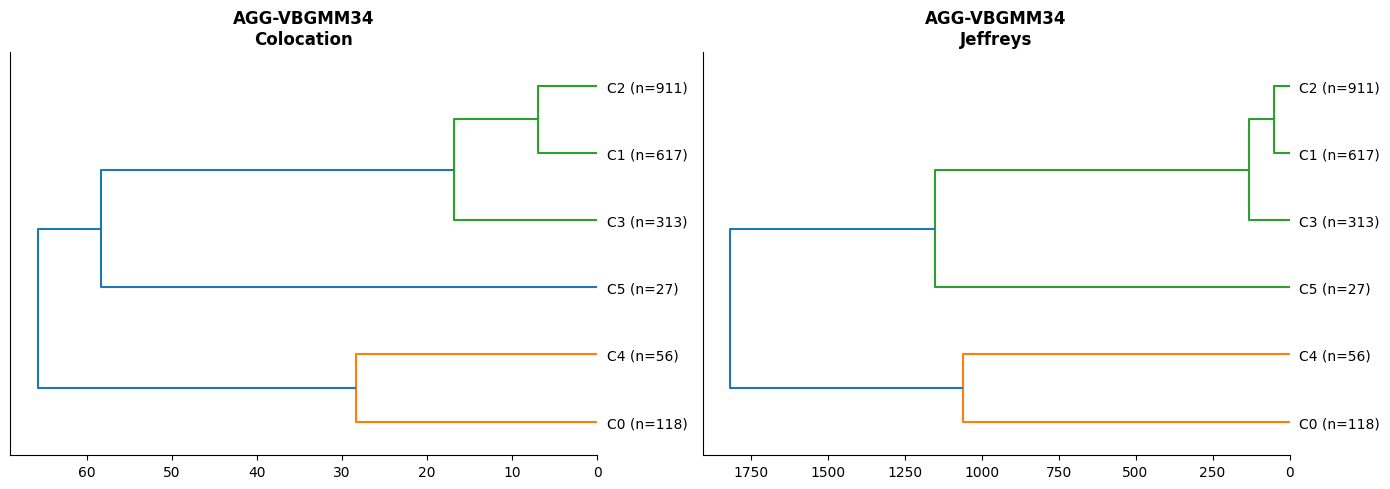

Significant features: 54

=== GNN-GMM ===


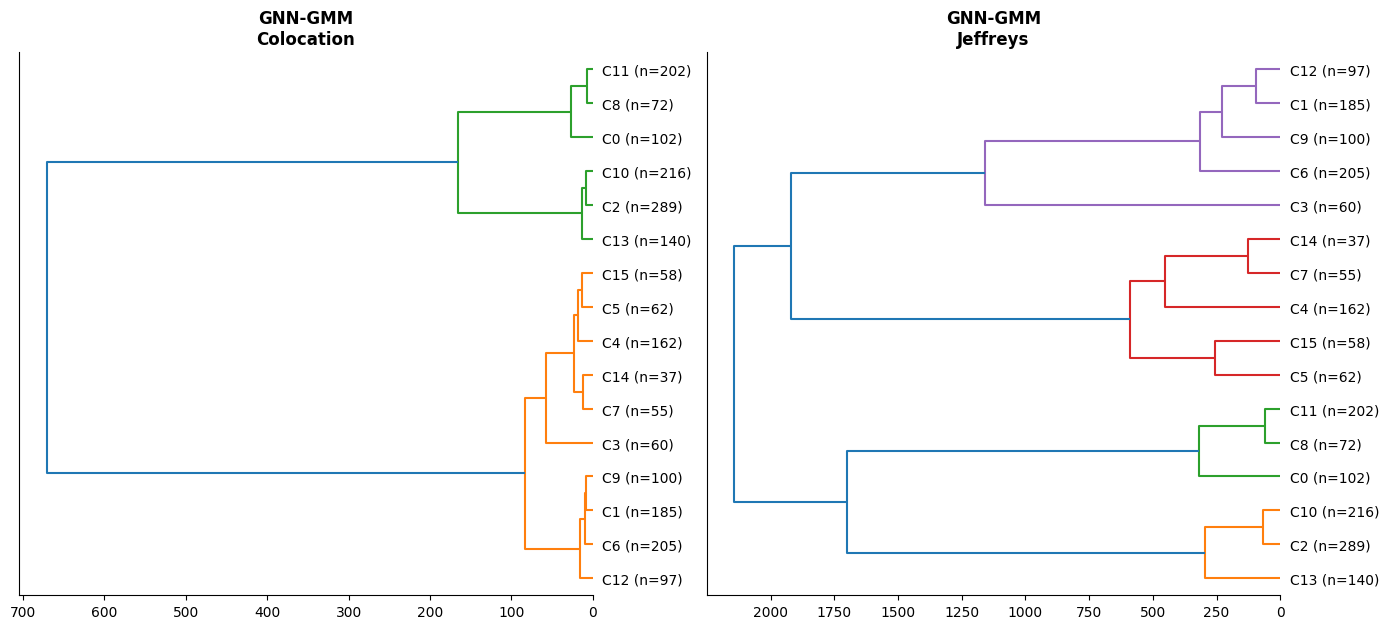

Significant features: 57

=== GNN-VBGMM ===


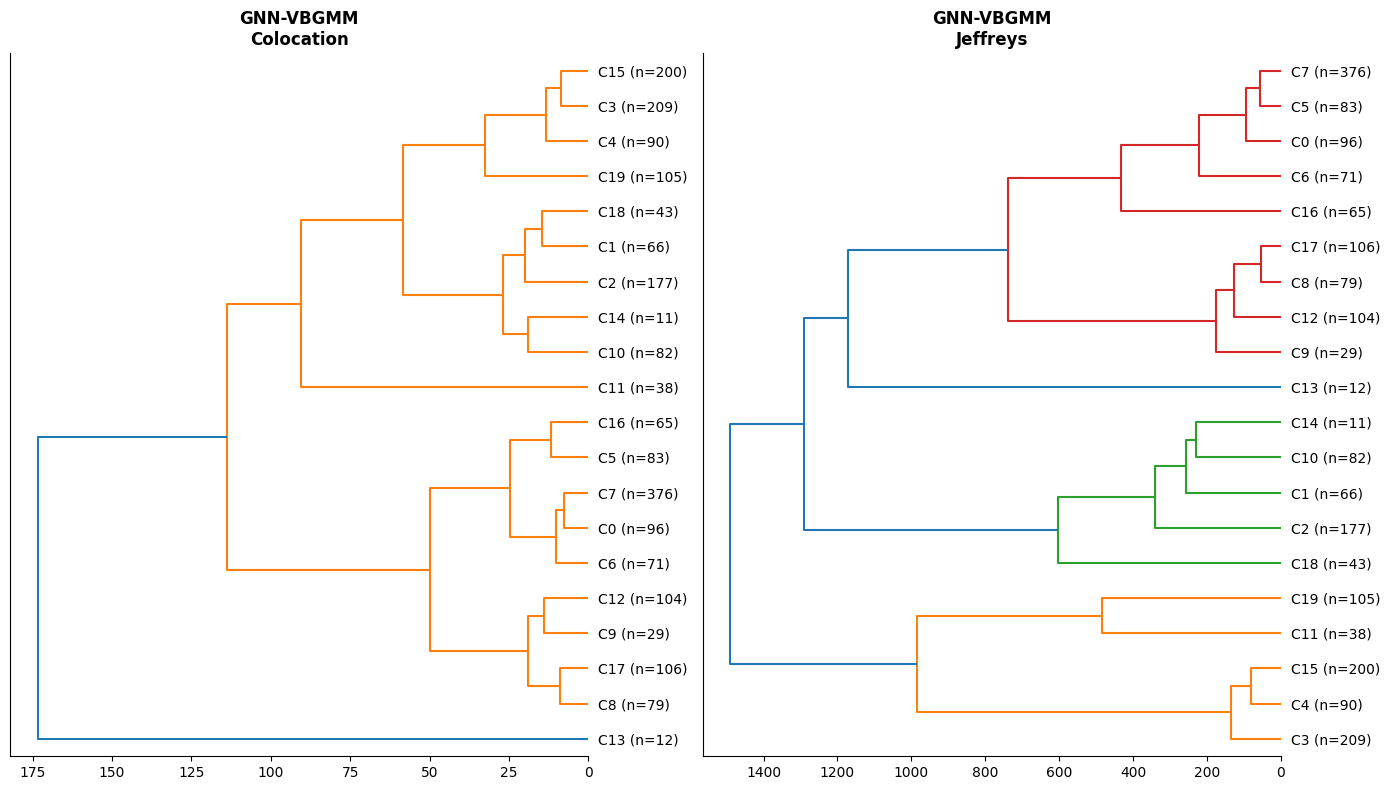

Significant features: 56


In [17]:
agg = pd.read_csv("../source/agg_final.csv")

models = {
    "AGG-GMM":   ("../results/classical_agg_10_GMM_QIn.npy",
                  "../source/agg_trans.csv"),
    "AGG-VBGMM": ("../results/classical_agg_10_vbgmm_QIn.npy",
                  "../source/agg_trans.csv"),
    "AGG-VBGMM34": ("../results/classical_agg_34_vbgmm_QIn.npy",
                    "../source/agg_trans.csv"),
    "GNN-GMM":   ("../results/GNN_s2s_10_GMM_QIn.npy",
                  "../source/GNN_set2set_ALL_FOLDS.csv"),
    "GNN-VBGMM": ("../results/GNN_s2s_10_vbgmm_QIn.npy",
                  "../source/GNN_set2set_ALL_FOLDS.csv"),
}

dfs_sc = {}
effects_sc = {}

for name, (qin_path, exp_path) in models.items():
    df, effects = run_model_pipeline(
        name, qin_path, exp_path, agg, evms,
        min_size=10,
        use_anova=False
    )

    dfs_sc[name] = df
    effects_sc[name] = effects
    
eff_mat = pd.concat(
    {k: v.set_index("feature")["effect"]
     for k, v in effects_sc.items()},
    axis=1
)

## 4 · Feature Discriminability — Effect Size Bar Chart

This plot compares the **top discriminating physicochemical features** across the three aggregated-feature clustering models (AGG-GMM, AGG-VBGMM, AGG-VBGMM34).

**Effect size metric:** (epsilon-squared) from the Kruskal-Wallis H-test:

$$\varepsilon^2 = \frac{H}{\frac{n^2 - 1}{n + 1}}$$

where *H* is the KW test statistic and *n* is the total number of observations. Values range from 0 (no separation) to 1 (perfect separation).

The union of the top-7 features from each model is shown, sorted by AGG-GMM effect size.  
**Key finding:** GMM-derived superclusters are primarily discriminated by amino acid composition features (hydrophobic and charged residues), consistent with the supervised analysis. VBGMM34 additionally highlights contact-type counts (π-stacking, T-stacking).

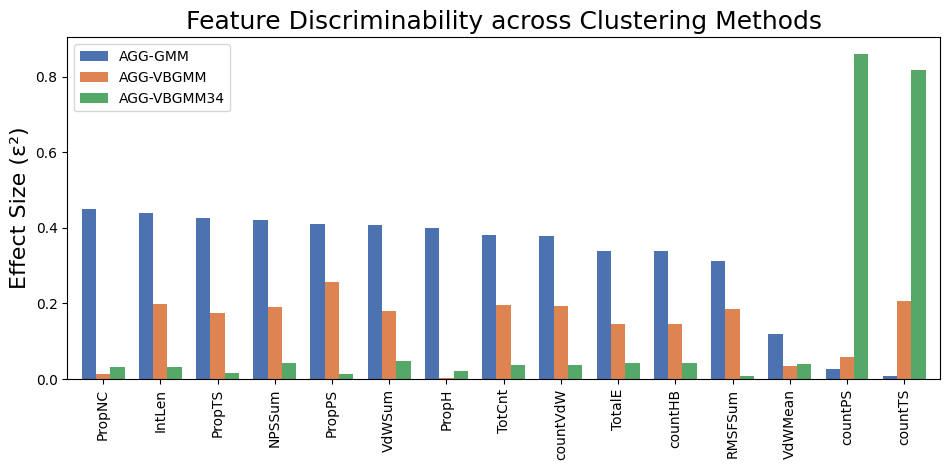

In [18]:
usan.plot_final_clustering_effects(eff_mat, '../source/feature_names2_accronyms.csv')
plt.savefig("../figures/effect_size_clustering.png")
plt.show()

## 5 · Feature Discriminability — Full Heatmap

This heatmap shows the Kruskal-Wallis effect size for the **top 64 features** (ranked by mean effect size across all five models).

- **Colour intensity** encodes effect size: white ( around 0) to  orange to red (high discriminability)
- **Asterisk (*)** marks features where the Benjamini-Hochberg adjusted p-value < 0.05
- **Rows** are features; **columns** are models

This view allows direct comparison of which features drive cluster separation in aggregated vs. GNN representations, and GMM vs. VBGMM clustering.

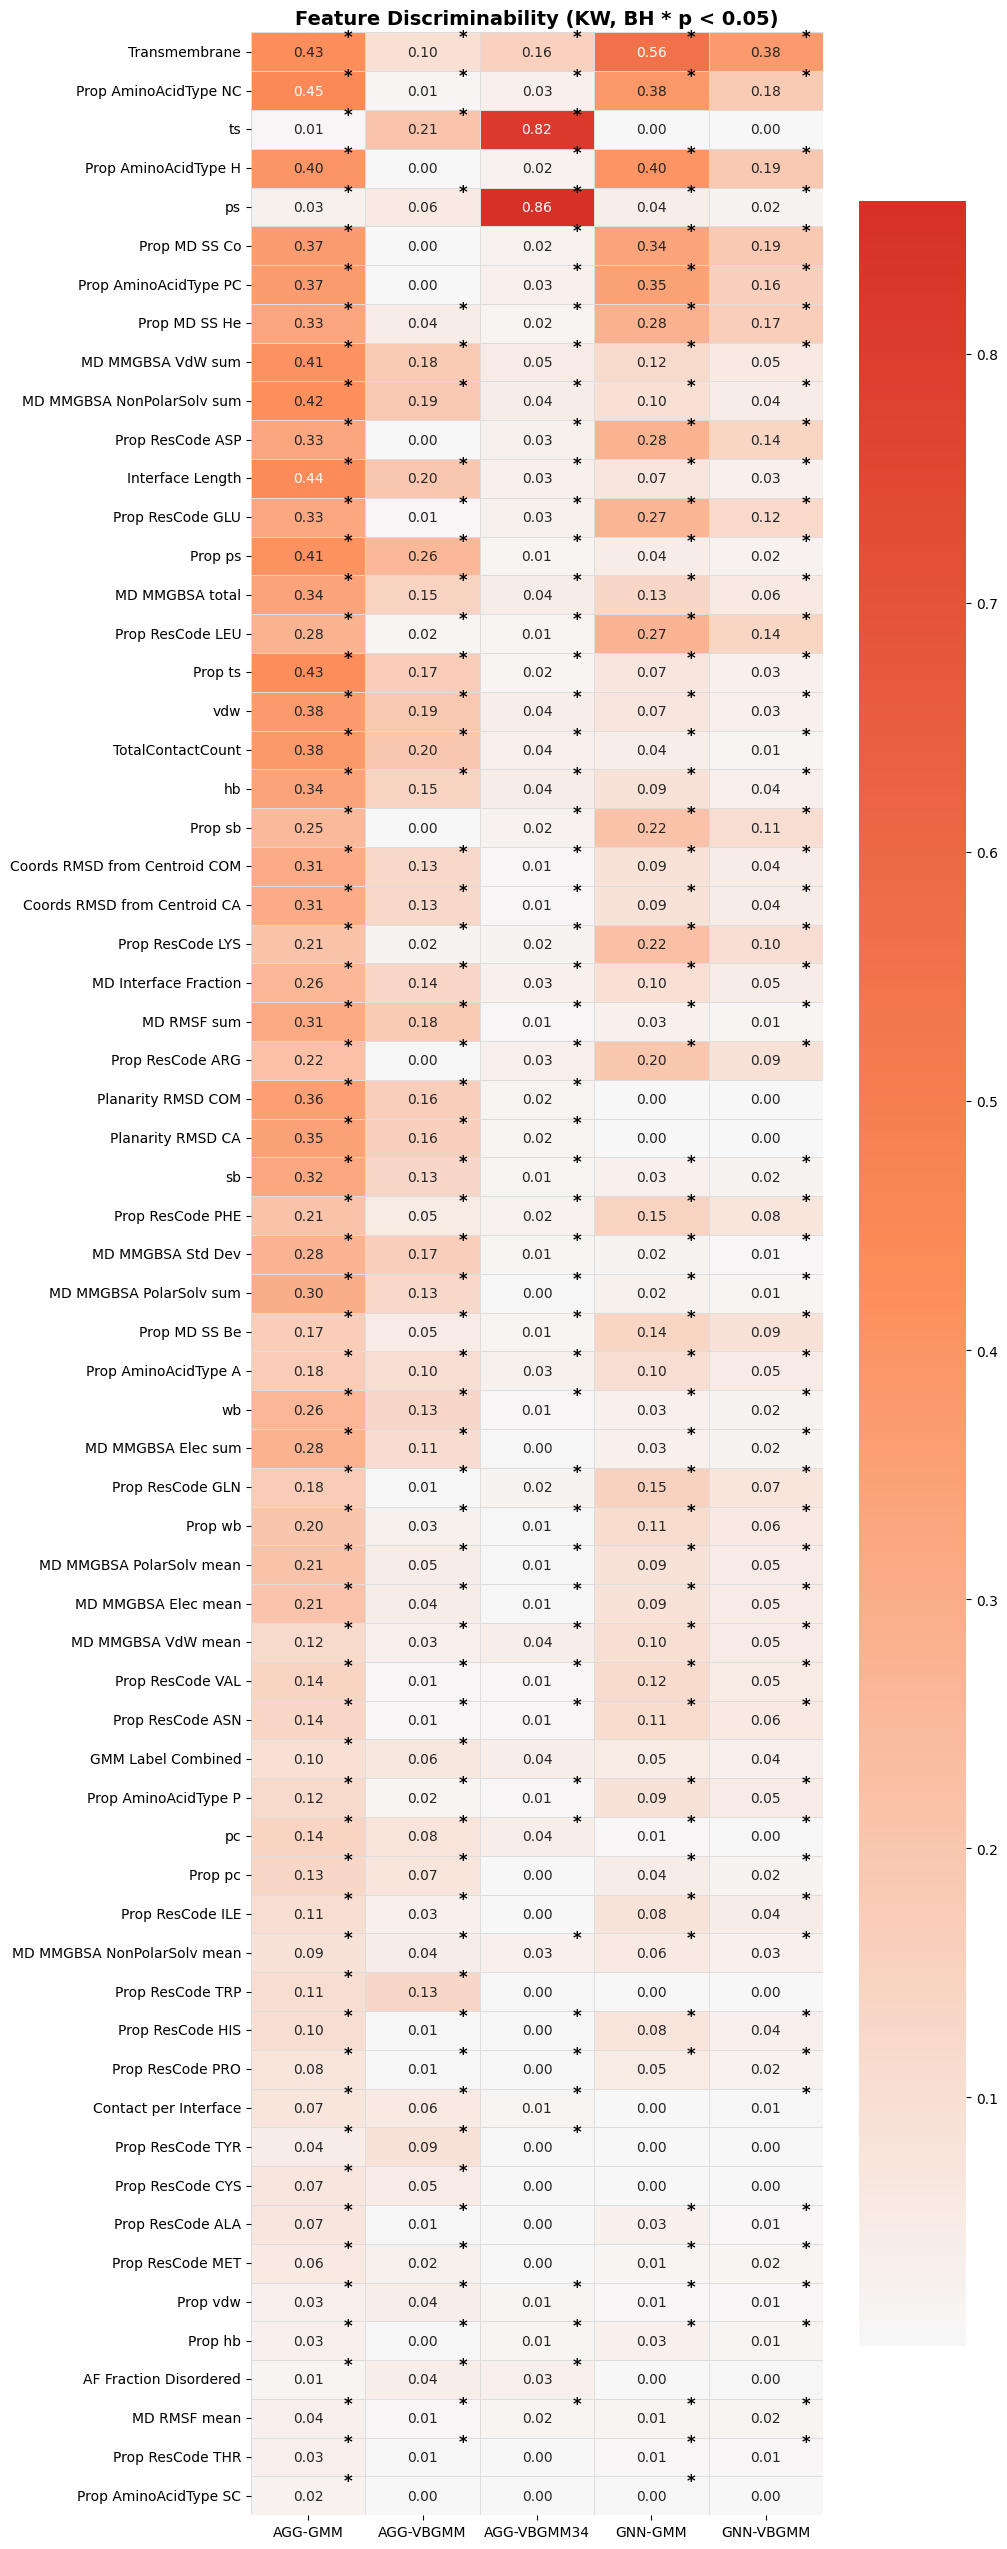

In [19]:
usan.plot_heatmap(effects_sc)